In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
%matplotlib inline

In [3]:
base_path = 'D:/demand_forecasting/'

train = pd.read_csv(base_path + 'train.csv', parse_dates=['date'])
test = pd.read_csv(base_path + 'test.csv', parse_dates=['date'])
stores = pd.read_csv(base_path + 'stores.csv')
oil = pd.read_csv(base_path + 'oil.csv', parse_dates=['date'])
holidays = pd.read_csv(base_path + 'holidays_events.csv', parse_dates=['date'])
transactions = pd.read_csv(base_path + 'transactions.csv', parse_dates=['date'])

print(train.shape, test.shape, stores.shape, oil.shape, holidays.shape, transactions.shape)

(3000888, 6) (28512, 5) (54, 5) (1218, 2) (350, 6) (83488, 3)


In [7]:


dfs = {
    'train': train,
    'test': test,
    'stores': stores,
    'oil': oil,
    'holidays': holidays,
    'transactions': transactions
}

for name, df in dfs.items():
   
    print(f"\n{'='*50}")
    print(f"DATASET: {name}")
    print(f"{'='*50}")
    print(f"Shape: {df.shape}")
    print(f"\nHead:\n{df.head()}")
    print(f"\nInfo:")
    df.info()
    print(f"\nMissing values:\n{df.isnull().sum()}")


DATASET: train
Shape: (3000888, 6)

Head:
   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0
3   3 2013-01-01          1   BEVERAGES    0.0            0
4   4 2013-01-01          1       BOOKS    0.0            0

Info:
<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[us]
 2   store_nbr    int64         
 3   family       str           
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[us](1), float64(1), int64(3), str(1)
memory usage: 137.4 MB

Missing values:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

DATASET: test

In [9]:

# Step 1: Merge stores onto train and test
train_merged = train.merge(stores, on='store_nbr', how='left')
test_merged = test.merge(stores, on='store_nbr', how='left')

print("After stores merge:", train_merged.shape, test_merged.shape)


After stores merge: (3000888, 10) (28512, 9)


In [10]:
# Reindex oil to include EVERY calendar date
full_dates = pd.date_range(start=train['date'].min(), end=test['date'].max(), freq='D')
oil_full = oil.set_index('date').reindex(full_dates).reset_index()
oil_full.columns = ['date', 'dcoilwtico']
oil_full['dcoilwtico'] = oil_full['dcoilwtico'].ffill().bfill()

train_merged = train_merged.merge(oil_full, on='date', how='left')
test_merged = test_merged.merge(oil_full, on='date', how='left')

print("After oil merge:", train_merged.shape, test_merged.shape)
print(train_merged['dcoilwtico'].isnull().sum())


After oil merge: (3000888, 11) (28512, 10)
0


In [11]:
# Step 3: Clean holidays BEFORE merging — dedupe so we don't multiply rows
# Keep only non-transferred holidays, drop duplicate dates (keep first)
holidays_clean = holidays[holidays['transferred'] == False].copy()
holidays_clean = holidays_clean.drop_duplicates(subset='date', keep='first')
holidays_clean = holidays_clean[['date', 'type', 'locale', 'description']]
holidays_clean = holidays_clean.rename(columns={'type': 'holiday_type'})

train_merged = train_merged.merge(holidays_clean, on='date', how='left')
test_merged = test_merged.merge(holidays_clean, on='date', how='left')

print("After holidays merge:", train_merged.shape, test_merged.shape)

After holidays merge: (3000888, 14) (28512, 13)


In [12]:
# Step 4: Merge transactions (only exists in train period, not test)
train_merged = train_merged.merge(transactions, on=['date', 'store_nbr'], how='left')

print("After transactions merge:", train_merged.shape)

After transactions merge: (3000888, 15)


In [13]:
train_merged.isnull().sum()

id                    0
date                  0
store_nbr             0
family                0
sales                 0
onpromotion           0
city                  0
state                 0
type                  0
cluster               0
dcoilwtico            0
holiday_type    2567862
locale          2567862
description     2567862
transactions     245784
dtype: int64

In [14]:
# Rename oil column for clarity (optional but recommended)
train_merged = train_merged.rename(columns={'dcoilwtico': 'oil_price'})
test_merged = test_merged.rename(columns={'dcoilwtico': 'oil_price'})

# Create a simple is_holiday flag (1 if that date had a holiday, else 0)
train_merged['is_holiday'] = train_merged['holiday_type'].notnull().astype(int)
test_merged['is_holiday'] = test_merged['holiday_type'].notnull().astype(int)

# Fill missing transactions with 0 (no record = no transactions that day)
train_merged['transactions'] = train_merged['transactions'].fillna(0)

# Now drop the raw holiday columns we no longer need in this simple form
train_merged = train_merged.drop(columns=['holiday_type', 'locale', 'description'])
test_merged = test_merged.drop(columns=['holiday_type', 'locale', 'description'])

# Final check
print(train_merged.isnull().sum())
print(test_merged.isnull().sum())

id              0
date            0
store_nbr       0
family          0
sales           0
onpromotion     0
city            0
state           0
type            0
cluster         0
oil_price       0
transactions    0
is_holiday      0
dtype: int64
id             0
date           0
store_nbr      0
family         0
onpromotion    0
city           0
state          0
type           0
cluster        0
oil_price      0
is_holiday     0
dtype: int64


In [15]:
train_merged.to_csv('D:/demand_forecasting/train_merged.csv', index=False)
test_merged.to_csv('D:/demand_forecasting/test_merged.csv', index=False)

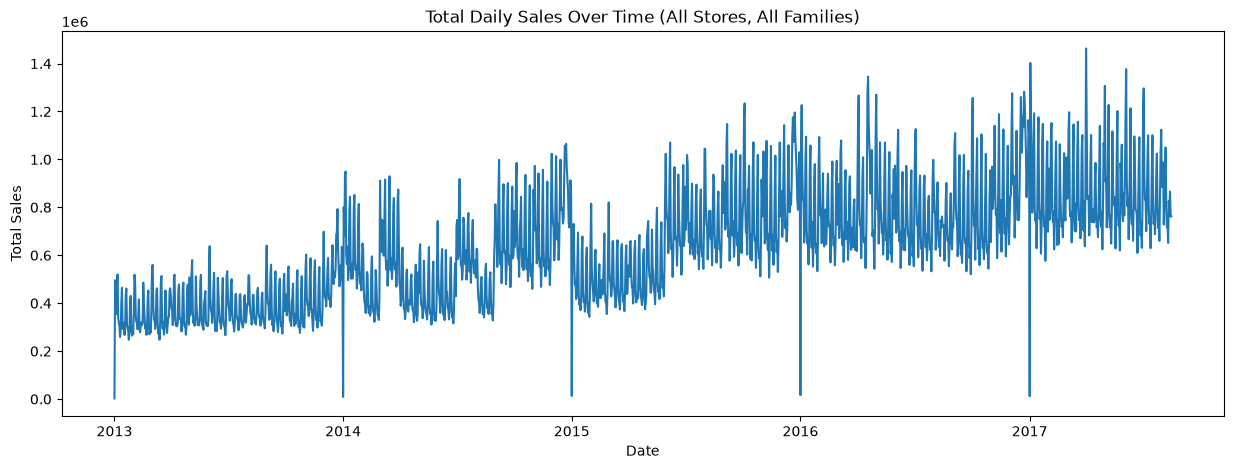

In [16]:
# Overall sales trend over time
daily_sales = train_merged.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(15, 5))
plt.plot(daily_sales['date'], daily_sales['sales'])
plt.title('Total Daily Sales Over Time (All Stores, All Families)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

In [17]:
# Find the dates with the lowest total sales
daily_sales_sorted = daily_sales.sort_values('sales').head(10)
print(daily_sales_sorted)

           date          sales
0    2013-01-01    2511.618999
364  2014-01-01    8602.065404
1457 2017-01-01   12082.500997
728  2015-01-01   12773.616980
1092 2016-01-01   16433.394000
23   2013-01-24  247245.690995
72   2013-03-14  247541.420096
9    2013-01-10  258982.003049
28   2013-01-29  264488.818076
177  2013-06-27  266525.458966


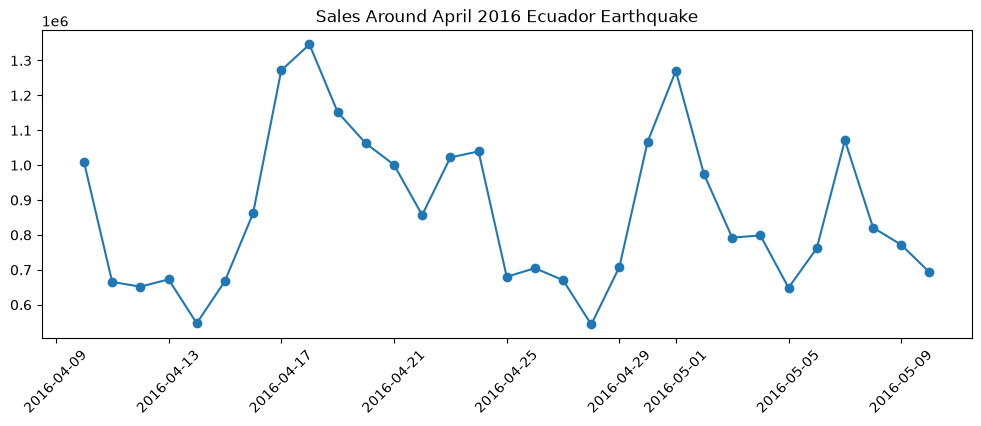

In [18]:
# 1. Check around the April 2016 Ecuador earthquake for a sales spike
earthquake_window = daily_sales[(daily_sales['date'] >= '2016-04-10') & (daily_sales['date'] <= '2016-05-10')]
plt.figure(figsize=(12,4))
plt.plot(earthquake_window['date'], earthquake_window['sales'], marker='o')
plt.title('Sales Around April 2016 Ecuador Earthquake')
plt.xticks(rotation=45)
plt.show()

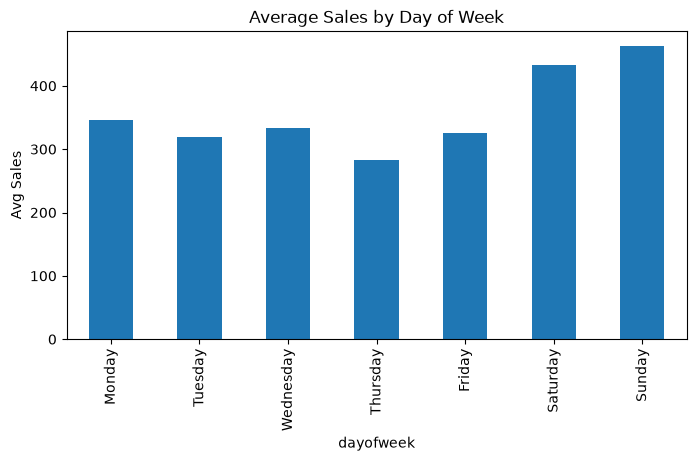

In [19]:
# 2. Check day-of-week seasonality
train_merged['dayofweek'] = train_merged['date'].dt.day_name()
dow_sales = train_merged.groupby('dayofweek')['sales'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)
plt.figure(figsize=(8,4))
dow_sales.plot(kind='bar')
plt.title('Average Sales by Day of Week')
plt.ylabel('Avg Sales')
plt.show()



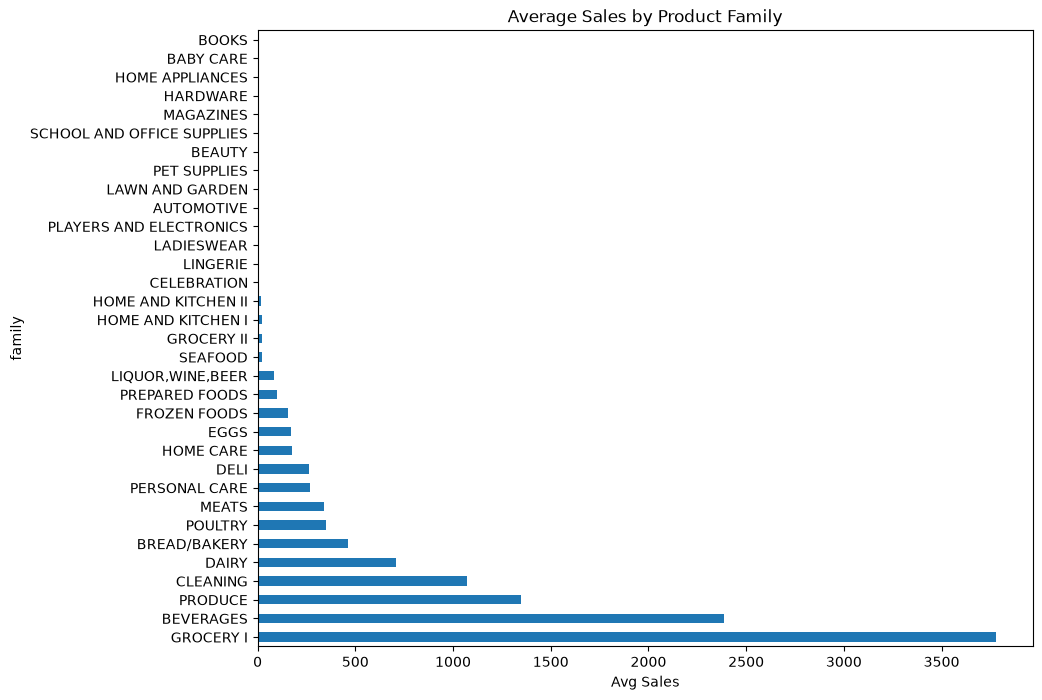

In [20]:
# 1. Sales distribution by product family (which families dominate volume?)
family_sales = train_merged.groupby('family')['sales'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,8))
family_sales.plot(kind='barh')
plt.title('Average Sales by Product Family')
plt.xlabel('Avg Sales')
plt.show()

In [21]:
# 2. Proportion of zero-sales rows (relevant since RMSLE is sensitive to this)
zero_sales_pct = (train_merged['sales'] == 0).mean() * 100
print(f"Percentage of rows with zero sales: {zero_sales_pct:.2f}%")

Percentage of rows with zero sales: 31.30%


In [22]:
for df in [train_merged, test_merged]:
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek        # 0=Monday ... 6=Sunday
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)

# Earthquake flag (April 16, 2016 and the following ~2 weeks of elevated sales)
earthquake_start = pd.Timestamp('2016-04-16')
earthquake_end = pd.Timestamp('2016-05-01')
train_merged['is_earthquake_period'] = train_merged['date'].between(earthquake_start, earthquake_end).astype(int)
test_merged['is_earthquake_period'] = test_merged['date'].between(earthquake_start, earthquake_end).astype(int)

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

cat_cols = ['family', 'city', 'state', 'type']
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    train_merged[col + '_enc'] = le.fit_transform(train_merged[col])
    test_merged[col + '_enc'] = le.transform(test_merged[col])
    encoders[col] = le

print(train_merged.shape, test_merged.shape)
print(train_merged.columns.tolist())

(3000888, 24) (28512, 22)
['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state', 'type', 'cluster', 'oil_price', 'transactions', 'is_holiday', 'dayofweek', 'year', 'month', 'day', 'is_weekend', 'weekofyear', 'is_earthquake_period', 'family_enc', 'city_enc', 'state_enc', 'type_enc']


In [23]:
# Sort first — CRITICAL for lag features to be correct
train_merged = train_merged.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)

# Create lag features per store+family group
for lag in [1, 7, 14]:
    train_merged[f'sales_lag_{lag}'] = train_merged.groupby(['store_nbr', 'family'])['sales'].shift(lag)

# Rolling mean/std (using shifted data to avoid leakage)
for window in [7, 14]:
    train_merged[f'sales_rollmean_{window}'] = (
        train_merged.groupby(['store_nbr', 'family'])['sales']
        .shift(1)
        .rolling(window)
        .mean()
    )

print(train_merged[['store_nbr','family','date','sales','sales_lag_1','sales_lag_7','sales_rollmean_7']].head(20))
print(train_merged.isnull().sum()[['sales_lag_1','sales_lag_7','sales_lag_14','sales_rollmean_7','sales_rollmean_14']])

    store_nbr      family       date  sales  sales_lag_1  sales_lag_7  \
0           1  AUTOMOTIVE 2013-01-01    0.0          NaN          NaN   
1           1  AUTOMOTIVE 2013-01-02    2.0          0.0          NaN   
2           1  AUTOMOTIVE 2013-01-03    3.0          2.0          NaN   
3           1  AUTOMOTIVE 2013-01-04    3.0          3.0          NaN   
4           1  AUTOMOTIVE 2013-01-05    5.0          3.0          NaN   
5           1  AUTOMOTIVE 2013-01-06    2.0          5.0          NaN   
6           1  AUTOMOTIVE 2013-01-07    0.0          2.0          NaN   
7           1  AUTOMOTIVE 2013-01-08    2.0          0.0          0.0   
8           1  AUTOMOTIVE 2013-01-09    2.0          2.0          2.0   
9           1  AUTOMOTIVE 2013-01-10    2.0          2.0          3.0   
10          1  AUTOMOTIVE 2013-01-11    3.0          2.0          3.0   
11          1  AUTOMOTIVE 2013-01-12    2.0          3.0          5.0   
12          1  AUTOMOTIVE 2013-01-13    2.0        

In [24]:
# Drop rows where the longest lag/rolling window isn't available yet
train_final = train_merged.dropna(subset=['sales_lag_14', 'sales_rollmean_14']).reset_index(drop=True)

print("Before:", train_merged.shape)
print("After dropping cold-start rows:", train_final.shape)

Before: (3000888, 29)
After dropping cold-start rows: (2975940, 29)


In [25]:
# Rolling mean of promotions (recent promo activity, shifted to avoid leakage)
for window in [7]:
    train_final[f'promo_rollmean_{window}'] = (
        train_final.groupby(['store_nbr', 'family'])['onpromotion']
        .shift(1)
        .rolling(window)
        .mean()
    )

# Change in promotion count from the previous day (did promo intensity increase/decrease?)
train_final['promo_diff'] = (
    train_final.groupby(['store_nbr', 'family'])['onpromotion']
    .diff(1)
)

print(train_final[['store_nbr','family','date','onpromotion','promo_rollmean_7','promo_diff']].head(15))
print(train_final[['promo_rollmean_7','promo_diff']].isnull().sum())

    store_nbr      family       date  onpromotion  promo_rollmean_7  \
0           1  AUTOMOTIVE 2013-01-15            0               NaN   
1           1  AUTOMOTIVE 2013-01-16            0               NaN   
2           1  AUTOMOTIVE 2013-01-17            0               NaN   
3           1  AUTOMOTIVE 2013-01-18            0               NaN   
4           1  AUTOMOTIVE 2013-01-19            0               NaN   
5           1  AUTOMOTIVE 2013-01-20            0               NaN   
6           1  AUTOMOTIVE 2013-01-21            0               NaN   
7           1  AUTOMOTIVE 2013-01-22            0               0.0   
8           1  AUTOMOTIVE 2013-01-23            0               0.0   
9           1  AUTOMOTIVE 2013-01-24            0               0.0   
10          1  AUTOMOTIVE 2013-01-25            0               0.0   
11          1  AUTOMOTIVE 2013-01-26            0               0.0   
12          1  AUTOMOTIVE 2013-01-27            0               0.0   
13    

In [26]:
train_final['promo_rollmean_7'] = train_final['promo_rollmean_7'].fillna(0)
train_final['promo_diff'] = train_final['promo_diff'].fillna(0)

print(train_final.isnull().sum().sum())  # should be 0 now across the whole dataframe

0


In [27]:
train_final.to_csv('D:/demand_forecasting/train_final.csv', index=False)

print(train_final['sales'].describe())

count    2.975940e+06
mean     3.591357e+02
std      1.104695e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.970000e+02
max      1.247170e+05
Name: sales, dtype: float64


In [28]:
import tensorflow as tf
import pandas as pd

In [29]:
train_final = pd.read_csv('D:/demand_forecasting/train_final.csv', parse_dates=['date'])
print(train_final.shape)
print(train_final['sales'].describe())

(2975940, 31)
count    2.975940e+06
mean     3.591357e+02
std      1.104695e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.970000e+02
max      1.247170e+05
Name: sales, dtype: float64


In [30]:
# ============================================
# STEP 4A: Time-based train/validation split
# ============================================
max_date = train_final['date'].max()
cutoff_date = max_date - pd.Timedelta(days=15)

train_split = train_final[train_final['date'] <= cutoff_date].reset_index(drop=True)
val_split = train_final[train_final['date'] > cutoff_date].reset_index(drop=True)

print("Train shape:", train_split.shape)
print("Validation shape:", val_split.shape)
print(train_split['sales'].describe())

Train shape: (2949210, 31)
Validation shape: (26730, 31)
count    2.949210e+06
mean     3.581749e+02
std      1.103302e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.960000e+02
max      1.247170e+05
Name: sales, dtype: float64


In [31]:
# STEP 4B: Scaling 
from sklearn.preprocessing import StandardScaler
import numpy as np

feature_cols = [
    'onpromotion', 'oil_price', 'transactions', 'is_holiday',
    'dayofweek', 'is_weekend', 'weekofyear', 'is_earthquake_period',
    'family_enc', 'city_enc', 'state_enc', 'type_enc', 'cluster',
    'sales_lag_1', 'sales_lag_7', 'sales_lag_14',
    'sales_rollmean_7', 'sales_rollmean_14',
    'promo_rollmean_7', 'promo_diff'
]

# Scale FEATURES only
scaler_X = StandardScaler()
train_split[feature_cols] = scaler_X.fit_transform(train_split[feature_cols])
val_split[feature_cols] = scaler_X.transform(val_split[feature_cols])

# TARGET: log1p transform instead of StandardScaler — no scaler_y needed, fixed/parameter-free
train_split['sales_log'] = np.log1p(train_split['sales'])
val_split['sales_log'] = np.log1p(val_split['sales'])

target_col = 'sales_log'   # use this everywhere from now on

print(train_split[feature_cols].describe())
print(train_split['sales_log'].describe())
print(val_split['sales_log'].describe())

        onpromotion     oil_price  transactions    is_holiday     dayofweek  \
count  2.949210e+06  2.949210e+06  2.949210e+06  2.949210e+06  2.949210e+06   
mean   1.110189e-17  1.148737e-17  1.184202e-16  1.539400e-17  2.320122e-18   
std    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00   
min   -2.122305e-01 -1.620729e+00 -1.505884e+00 -4.088237e-01 -1.498528e+00   
25%   -2.122305e-01 -8.416875e-01 -6.061612e-01 -4.088237e-01 -9.987170e-01   
50%   -2.122305e-01 -5.625696e-01 -2.182162e-01 -4.088237e-01  9.060027e-04   
75%   -2.122305e-01  1.086092e+00  4.067526e-01 -4.088237e-01  1.000529e+00   
max    6.041262e+01  1.661432e+00  6.580980e+00  2.446042e+00  1.500340e+00   

         is_weekend    weekofyear  is_earthquake_period    family_enc  \
count  2.949210e+06  2.949210e+06          2.949210e+06  2.949210e+06   
mean  -1.863913e-17 -2.128344e-17         -1.654683e-17  2.467087e-18   
std    1.000000e+00  1.000000e+00          1.000000e+00  1.000000e+00

In [32]:
# ============================================
# STEP 4C: Sequence-building functions
# ============================================
import numpy as np

def create_sequences_fast(df, feature_cols, target_col, group_cols=['store_nbr','family'], window=15):
    X_list, y_list = [], []
    for _, group in df.groupby(group_cols, sort=False):
        group = group.sort_values('date')
        feats = group[feature_cols].values.astype(np.float32)
        target = group[target_col].values.astype(np.float32)
        n = len(feats)
        if n <= window:
            continue
        windows = np.lib.stride_tricks.sliding_window_view(feats, window_shape=window, axis=0)
        windows = np.moveaxis(windows, -1, 1)
        X_list.append(windows[:-1])
        y_list.append(target[window:])
    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    return X, y

def create_sequences_with_dates(df, feature_cols, target_col, group_cols=['store_nbr','family'], window=15):
    X_list, y_list, date_list = [], [], []
    for _, group in df.groupby(group_cols, sort=False):
        group = group.sort_values('date')
        feats = group[feature_cols].values.astype(np.float32)
        target = group[target_col].values.astype(np.float32)
        dates = group['date'].values
        n = len(feats)
        if n <= window:
            continue
        windows = np.lib.stride_tricks.sliding_window_view(feats, window_shape=window, axis=0)
        windows = np.moveaxis(windows, -1, 1)
        X_list.append(windows[:-1])
        y_list.append(target[window:])
        date_list.append(dates[window:])
    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    dates = np.concatenate(date_list, axis=0)
    return X, y, dates

In [33]:
# ============================================
# STEP 4D: Build TRAIN sequences
# ============================================
X_train, y_train = create_sequences_fast(train_split, feature_cols, target_col, window=15)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (2922480, 15, 20)
y_train shape: (2922480,)


In [34]:
# ============================================
# STEP 4E: Build VAL sequences (leakage-free)
# ============================================
combined_for_val = pd.concat([
    train_split[train_split['date'] > train_split['date'].max() - pd.Timedelta(days=30)],
    val_split
]).sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)

X_val_raw, y_val_raw, val_dates = create_sequences_with_dates(
    combined_for_val, feature_cols, target_col, window=15
)

val_dates_reference = val_split['date'].values
mask = np.isin(val_dates, val_dates_reference)

X_val = X_val_raw[mask]
y_val = y_val_raw[mask]

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_val shape: (26730, 15, 20)
y_val shape: (26730,)


In [36]:
batch_size = 256
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(buffer_size=10000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]

rnn_model = Sequential([
    Input(shape=(n_timesteps, n_features)),
    SimpleRNN(64, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

rnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
rnn_model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 64)                  │           5,440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,553 (29.50 KB)

 Trainable params: 7,553 (29.50 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
history_rnn = rnn_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20


D:\demand_forecasting\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


11416/11416 ━━━━━━━━━━━━━━━━━━━━ 113s 9ms/step - loss: 0.7984 - mae: 0.6215 - val_loss: 0.6197 - val_mae: 0.5659
Epoch 2/20
11416/11416 ━━━━━━━━━━━━━━━━━━━━ 91s 8ms/step - loss: 0.5298 - mae: 0.4696 - val_loss: 0.3771 - val_mae: 0.4531
Epoch 3/20
11416/11416 ━━━━━━━━━━━━━━━━━━━━ 88s 8ms/step - loss: 0.5018 - mae: 0.4595 - val_loss: 1.8400 - val_mae: 0.9445
Epoch 4/20
11416/11416 ━━━━━━━━━━━━━━━━━━━━ 91s 8ms/step - loss: 0.5367 - mae: 0.4844 - val_loss: 0.4323 - val_mae: 0.4794
Epoch 5/20
11416/11416 ━━━━━━━━━━━━━━━━━━━━ 92s 8ms/step - loss: 0.4539 - mae: 0.4325 - val_loss: 0.4184 - val_mae: 0.4667


In [39]:
from sklearn.metrics import mean_squared_log_error
import numpy as np

pred_val_log = rnn_model.predict(X_val, batch_size=256)
pred_val_actual = np.expm1(pred_val_log).flatten()
y_val_actual = np.expm1(y_val)
pred_val_actual = np.clip(pred_val_actual, 0, None)

rmsle_rnn = np.sqrt(mean_squared_log_error(y_val_actual, pred_val_actual))
print("SimpleRNN Validation RMSLE:", rmsle_rnn)

105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
SimpleRNN Validation RMSLE: 0.6141245444210885


In [40]:
import random
import numpy as np
import tensorflow as tf

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [41]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([
    Input(shape=(n_timesteps, n_features)),
    LSTM(64, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          21,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,873 (93.25 KB)

 Trainable params: 23,873 (93.25 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
history_lstm = lstm_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20


D:\demand_forecasting\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


11416/11416 ━━━━━━━━━━━━━━━━━━━━ 254s 22ms/step - loss: 0.6654 - mae: 0.5481 - val_loss: 0.8906 - val_mae: 0.7585
Epoch 2/20
11416/11416 ━━━━━━━━━━━━━━━━━━━━ 259s 23ms/step - loss: 0.3947 - mae: 0.3996 - val_loss: 0.5481 - val_mae: 0.6026
Epoch 3/20
11416/11416 ━━━━━━━━━━━━━━━━━━━━ 260s 23ms/step - loss: 0.2990 - mae: 0.3490 - val_loss: 0.5075 - val_mae: 0.5921
Epoch 4/20
11416/11416 ━━━━━━━━━━━━━━━━━━━━ 265s 23ms/step - loss: 0.2579 - mae: 0.3221 - val_loss: 0.4048 - val_mae: 0.5201
Epoch 5/20
11416/11416 ━━━━━━━━━━━━━━━━━━━━ 262s 23ms/step - loss: 0.2624 - mae: 0.3241 - val_loss: 0.5990 - val_mae: 0.6448
Epoch 6/20
11416/11416 ━━━━━━━━━━━━━━━━━━━━ 265s 23ms/step - loss: 0.2293 - mae: 0.2997 - val_loss: 0.5958 - val_mae: 0.6428
Epoch 7/20
11416/11416 ━━━━━━━━━━━━━━━━━━━━ 263s 23ms/step - loss: 0.2202 - mae: 0.2925 - val_loss: 0.6334 - val_mae: 0.6602


In [43]:
pred_val_log_lstm = lstm_model.predict(X_val, batch_size=256)
pred_val_actual_lstm = np.expm1(pred_val_log_lstm).flatten()
pred_val_actual_lstm = np.clip(pred_val_actual_lstm, 0, None)

rmsle_lstm = np.sqrt(mean_squared_log_error(y_val_actual, pred_val_actual_lstm))
print("LSTM Validation RMSLE:", rmsle_lstm)

105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
LSTM Validation RMSLE: 0.6362481513680392


In [44]:
from tensorflow.keras.layers import GRU

gru_model = Sequential([
    Input(shape=(n_timesteps, n_features)),
    GRU(64, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 64)                  │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,625 (72.75 KB)

 Trainable params: 18,625 (72.75 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
history_gru = gru_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20


D:\demand_forecasting\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


11416/11416 ━━━━━━━━━━━━━━━━━━━━ 250s 22ms/step - loss: 0.6812 - mae: 0.5504 - val_loss: 1.0356 - val_mae: 0.7749
Epoch 2/20
11416/11416 ━━━━━━━━━━━━━━━━━━━━ 378s 33ms/step - loss: 0.3963 - mae: 0.4022 - val_loss: 0.5435 - val_mae: 0.5633
Epoch 3/20
11416/11416 ━━━━━━━━━━━━━━━━━━━━ 381s 33ms/step - loss: 0.3207 - mae: 0.3619 - val_loss: 0.5046 - val_mae: 0.5622
Epoch 4/20
11416/11416 ━━━━━━━━━━━━━━━━━━━━ 383s 34ms/step - loss: 0.2816 - mae: 0.3378 - val_loss: 0.4293 - val_mae: 0.5291
Epoch 5/20
11416/11416 ━━━━━━━━━━━━━━━━━━━━ 382s 33ms/step - loss: 0.2595 - mae: 0.3228 - val_loss: 0.4709 - val_mae: 0.5370
Epoch 6/20
11416/11416 ━━━━━━━━━━━━━━━━━━━━ 385s 34ms/step - loss: 0.2563 - mae: 0.3195 - val_loss: 0.4313 - val_mae: 0.5239
Epoch 7/20
11416/11416 ━━━━━━━━━━━━━━━━━━━━ 385s 34ms/step - loss: 0.2350 - mae: 0.3045 - val_loss: 0.4490 - val_mae: 0.5314


In [46]:
pred_val_log_gru = gru_model.predict(X_val, batch_size=256)
pred_val_actual_gru = np.expm1(pred_val_log_gru).flatten()
pred_val_actual_gru = np.clip(pred_val_actual_gru, 0, None)

rmsle_gru = np.sqrt(mean_squared_log_error(y_val_actual, pred_val_actual_gru))
print("GRU Validation RMSLE:", rmsle_gru)

105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
GRU Validation RMSLE: 0.6552418503631082


In [47]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D

cnn_lstm_model = Sequential([
    Input(shape=(n_timesteps, n_features)),
    Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    LSTM(64, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

cnn_lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
cnn_lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 15, 32)              │           1,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 7, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 28,897 (112.88 KB)

 Trainable params: 28,897 (112.88 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
history_cnn_lstm = cnn_lstm_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20


D:\demand_forecasting\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


11416/11416 ━━━━━━━━━━━━━━━━━━━━ 237s 20ms/step - loss: 0.6155 - mae: 0.5266 - val_loss: 1.4157 - val_mae: 0.8511
Epoch 2/20
11416/11416 ━━━━━━━━━━━━━━━━━━━━ 269s 21ms/step - loss: 0.3815 - mae: 0.3941 - val_loss: 0.6250 - val_mae: 0.6083
Epoch 3/20
11416/11416 ━━━━━━━━━━━━━━━━━━━━ 239s 21ms/step - loss: 0.3206 - mae: 0.3549 - val_loss: 0.4207 - val_mae: 0.5076
Epoch 4/20
11416/11416 ━━━━━━━━━━━━━━━━━━━━ 242s 21ms/step - loss: 0.2812 - mae: 0.3329 - val_loss: 0.3566 - val_mae: 0.4639
Epoch 5/20
11416/11416 ━━━━━━━━━━━━━━━━━━━━ 241s 21ms/step - loss: 0.2579 - mae: 0.3174 - val_loss: 0.3841 - val_mae: 0.4888
Epoch 6/20
11416/11416 ━━━━━━━━━━━━━━━━━━━━ 241s 21ms/step - loss: 0.2536 - mae: 0.3141 - val_loss: 0.4457 - val_mae: 0.5314
Epoch 7/20
11416/11416 ━━━━━━━━━━━━━━━━━━━━ 269s 22ms/step - loss: 0.2370 - mae: 0.3030 - val_loss: 0.4394 - val_mae: 0.5263


In [53]:
pred_val_log_cnn_lstm = cnn_lstm_model.predict(X_val, batch_size=256)
pred_val_actual_cnn_lstm = np.expm1(pred_val_log_cnn_lstm).flatten()
pred_val_actual_cnn_lstm = np.clip(pred_val_actual_cnn_lstm, 0, None)

rmsle_cnn_lstm = np.sqrt(mean_squared_log_error(y_val_actual, pred_val_actual_cnn_lstm))
print("CNN-LSTM Validation RMSLE:", rmsle_cnn_lstm)

105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step
CNN-LSTM Validation RMSLE: 0.5971816927688878


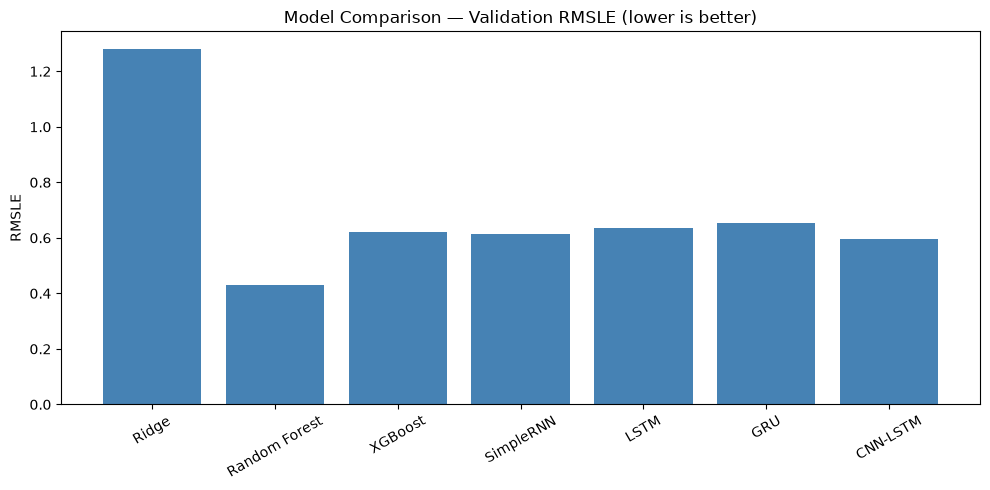

In [54]:
import matplotlib.pyplot as plt

models = ['Ridge', 'Random Forest', 'XGBoost', 'SimpleRNN', 'LSTM', 'GRU', 'CNN-LSTM']
rmsle_scores = [1.28, 0.43, 0.62, 0.6141, 0.6362, 0.6552, 0.5972]

plt.figure(figsize=(10, 5))
plt.bar(models, rmsle_scores, color='steelblue')
plt.title('Model Comparison — Validation RMSLE (lower is better)')
plt.ylabel('RMSLE')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

In [55]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_log_error
import numpy as np

X_train_flat = train_split[feature_cols]
y_train_flat = train_split['sales']   # raw sales — RF doesn't need log/scaling

X_val_flat = val_split[feature_cols]
y_val_flat_actual = val_split['sales']   # raw sales, for RMSLE comparison

# Subsample for faster training
sample_size = 300000
sample_idx = np.random.RandomState(42).choice(len(X_train_flat), sample_size, replace=False)

X_train_sample = X_train_flat.iloc[sample_idx]
y_train_sample = y_train_flat.iloc[sample_idx]

rf = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
rf.fit(X_train_sample, y_train_sample)

pred_rf = rf.predict(X_val_flat)
pred_rf = np.clip(pred_rf, 0, None)
rmsle_rf = np.sqrt(mean_squared_log_error(y_val_flat_actual, pred_rf))
print("Random Forest Validation RMSLE:", rmsle_rf)

Random Forest Validation RMSLE: 0.46038733658955266


In [57]:
# Pehle purane duplicate/partial columns hata de agar exist karte hain
cols_to_drop = ['promo_rollmean_7', 'promo_diff', 'promo_rollmean_7_x', 'promo_rollmean_7_y', 
                'promo_diff_x', 'promo_diff_y', 'transactions']
test_merged = test_merged.drop(columns=[c for c in cols_to_drop if c in test_merged.columns])

print(test_merged.columns.tolist())

['id', 'date', 'store_nbr', 'family', 'onpromotion', 'city', 'state', 'type', 'cluster', 'oil_price', 'is_holiday', 'year', 'month', 'day', 'dayofweek', 'is_weekend', 'weekofyear', 'is_earthquake_period', 'family_enc', 'city_enc', 'state_enc', 'type_enc']


In [58]:
import pandas as pd
import numpy as np

history_source = train_final[['store_nbr','family','date','sales']].sort_values(['store_nbr','family','date'])
sales_history = {}
for (store, fam), grp in history_source.groupby(['store_nbr','family']):
    sales_history[(store, fam)] = list(grp['sales'].values[-20:])

combined_promo = pd.concat([
    train_final[train_final['date'] > train_final['date'].max() - pd.Timedelta(days=30)][['store_nbr','family','date','onpromotion']],
    test_merged[['store_nbr','family','date','onpromotion']]
]).sort_values(['store_nbr','family','date']).reset_index(drop=True)

combined_promo['promo_rollmean_7'] = combined_promo.groupby(['store_nbr','family'])['onpromotion'].shift(1).rolling(7).mean()
combined_promo['promo_diff'] = combined_promo.groupby(['store_nbr','family'])['onpromotion'].diff(1)

test_promo = combined_promo.merge(test_merged[['store_nbr','family','date']], on=['store_nbr','family','date'], how='inner')
test_merged = test_merged.merge(test_promo[['store_nbr','family','date','promo_rollmean_7','promo_diff']], on=['store_nbr','family','date'], how='left')
test_merged['promo_rollmean_7'] = test_merged['promo_rollmean_7'].fillna(0)
test_merged['promo_diff'] = test_merged['promo_diff'].fillna(0)

last_transactions = train_final.sort_values('date').groupby('store_nbr')['transactions'].last()
test_merged['transactions'] = test_merged['store_nbr'].map(last_transactions).fillna(0)

test_merged = test_merged.sort_values('date').reset_index(drop=True)
predictions = []

for d in sorted(test_merged['date'].unique()):
    day_rows = test_merged[test_merged['date'] == d].copy()
    lag_1, lag_7, lag_14, roll_7, roll_14 = [], [], [], [], []

    for _, row in day_rows.iterrows():
        hist = sales_history.get((row['store_nbr'], row['family']), [0])
        lag_1.append(hist[-1])
        lag_7.append(hist[-7] if len(hist) >= 7 else 0)
        lag_14.append(hist[-14] if len(hist) >= 14 else 0)
        roll_7.append(np.mean(hist[-7:]))
        roll_14.append(np.mean(hist[-14:]))

    day_rows['sales_lag_1'] = lag_1
    day_rows['sales_lag_7'] = lag_7
    day_rows['sales_lag_14'] = lag_14
    day_rows['sales_rollmean_7'] = roll_7
    day_rows['sales_rollmean_14'] = roll_14

    X_day = scaler_X.transform(day_rows[feature_cols])
    day_preds = np.clip(rf.predict(X_day), 0, None)
    day_rows['sales_pred'] = day_preds
    predictions.append(day_rows[['id', 'sales_pred']])

    for (_, row), pred in zip(day_rows.iterrows(), day_preds):
        sales_history.setdefault((row['store_nbr'], row['family']), []).append(pred)

final_predictions = pd.concat(predictions).sort_values('id').reset_index(drop=True)
print(final_predictions.head())
print(final_predictions.shape)

D:\demand_forecasting\venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\demand_forecasting\venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\demand_forecasting\venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\demand_forecasting\venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\demand_forecasting\venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warni

        id   sales_pred
0  3000888     4.372634
1  3000889     0.580486
2  3000890     4.372634
3  3000891  2250.273283
4  3000892     0.580486
(28512, 2)


D:\demand_forecasting\venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [59]:
submission = final_predictions.rename(columns={'sales_pred': 'sales'})
submission.to_csv('D:/demand_forecasting/submission.csv', index=False)
print("Saved! Shape:", submission.shape)
print(submission.head())

Saved! Shape: (28512, 2)
        id        sales
0  3000888     4.372634
1  3000889     0.580486
2  3000890     4.372634
3  3000891  2250.273283
4  3000892     0.580486


In [60]:
print(test_merged[['id', 'date', 'store_nbr', 'family']].merge(submission, on='id').head(10))

        id       date  store_nbr        family        sales
0  3000888 2017-08-16          1    AUTOMOTIVE     4.372634
1  3001778 2017-08-16         33       SEAFOOD     0.604074
2  3000890 2017-08-16          1        BEAUTY     4.372634
3  3000891 2017-08-16          1     BEVERAGES  2250.273283
4  3000892 2017-08-16          1         BOOKS     0.580486
5  3000893 2017-08-16          1  BREAD/BAKERY   395.887607
6  3000894 2017-08-16          1   CELEBRATION     8.150044
7  3000895 2017-08-16          1      CLEANING   704.847924
8  3000896 2017-08-16          1         DAIRY   807.675733
9  3000897 2017-08-16          1          DELI   131.754809


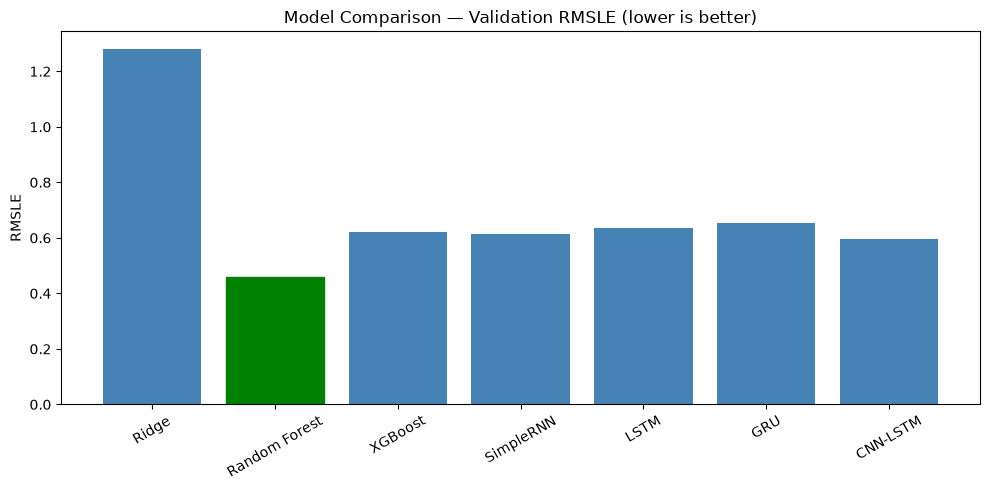

In [61]:
import matplotlib.pyplot as plt

models = ['Ridge', 'Random Forest', 'XGBoost', 'SimpleRNN', 'LSTM', 'GRU', 'CNN-LSTM']
rmsle_scores = [1.28, 0.46, 0.62, 0.6141, 0.6362, 0.6552, 0.5972]

plt.figure(figsize=(10, 5))
bars = plt.bar(models, rmsle_scores, color='steelblue')
bars[1].set_color('green')  # highlight best model
plt.title('Model Comparison — Validation RMSLE (lower is better)')
plt.ylabel('RMSLE')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('D:/demand_forecasting/model_comparison.png')
plt.show()